# Emotion Detection from Text — NLP Project

## Project Objective
The goal is to classify a person's emotion from text using Natural Language Processing (NLP). We will clean the text, create different numerical text representations, train multiple machine-learning models, tune the strongest model, and compare their performance.

**Dataset:** Emotions Dataset for NLP (Kaggle) — `train.txt`, `val.txt`, `test.txt`
Each line is formatted as `sentence;emotion` (semicolon-separated, no header).

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
import string

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt")
nltk.download("punkt_tab")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
import time

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 100)

sns.set_style("whitegrid")
%matplotlib inline

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


**Interpretation:** All libraries import successfully. The NLTK downloads report "already up-to-date" — meaning these resources (stopwords, WordNet, tokenizer models) were already cached locally from a previous run. This cell only needs to actually download anything the very first time it runs on a machine; afterward it's effectively a no-op check.

## Load the Dataset

The Kaggle dataset ships as three plain-text files (`train.txt`, `val.txt`, `test.txt`).

The dataset is loaded into three separate tables:

- **Training data**: used to teach the machine-learning models.
- **Validation data**: used during model selection and hyperparameter tuning.
- **Test data**: used only at the end to evaluate the final chosen model fairly.

Each record contains:

- `text`: a sentence written by a person.
- `emotion`: the target emotion category that the model must predict.

In [2]:
train_df = pd.read_csv(r"Emoticons data\train.txt", sep=";", header=None, names=["text", "emotion"])
val_df   = pd.read_csv(r"Emoticons data\val.txt",   sep=";", header=None, names=["text", "emotion"])
test_df  = pd.read_csv(r"Emoticons data\test.txt",  sep=";", header=None, names=["text", "emotion"])

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

train_df.head()

Train shape: (16000, 2)
Val shape:   (2000, 2)
Test shape:  (2000, 2)


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares ...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love
4,i am feeling grouchy,anger


**Interpretation:** The three splits load with the expected sizes — **16,000 train / 2,000 val / 2,000 test rows**, each with exactly two columns (`text`, `emotion`). The preview confirms the parsing is clean: no stray semicolons broke a row into the wrong columns, and labels look like sensible single words (`sadness`, `anger`, `love`).

### Initial Data Quality Checks

Before touching the text itself, we check for structural problems — missing values, duplicate rows, and how balanced the classes are — since each of these can silently distort model training if left unaddressed.

In [3]:
print("=== Train info ===")
train_df.info()

=== Train info ===
<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     16000 non-null  str  
 1   emotion  16000 non-null  str  
dtypes: str(2)
memory usage: 250.1 KB


In [4]:
print("\n=== Missing values ===")
print(train_df.isnull().sum())


=== Missing values ===
text       0
emotion    0
dtype: int64


In [5]:
print("\n=== Duplicate rows ===")
print("Train duplicates:", train_df.duplicated().sum())


=== Duplicate rows ===
Train duplicates: 1


In [6]:
print("\n=== Label distribution (train) ===")
print(train_df["emotion"].value_counts())


=== Label distribution (train) ===
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


**Interpretation:** No missing values in either column, and only **1 duplicate row** out of 16,000 (negligible — dropped in the next cell for cleanliness). The label distribution reveals **meaningful class imbalance**:

| Emotion | Count | % of train |
|---|---|---|
| joy | 5,362 | 33.5% |
| sadness | 4,666 | 29.2% |
| anger | 2,159 | 13.5% |
| fear | 1,937 | 12.1% |
| love | 1,304 | 8.2% |
| surprise | 572 | 3.6% |

`joy` and `sadness` together make up **~63%** of the data, while `surprise` is under **4%**. This has two direct consequences for later steps: (1) **accuracy alone would be misleading** — a model could score ~63% just by favoring joy/sadness and ignoring surprise/love entirely, which is why we standardize on **macro-F1** from Section 7 onward; and (2) we use `class_weight="balanced"` in every model that supports it, to penalize minority-class errors more heavily.

In [7]:
train_df = train_df.drop_duplicates().reset_index(drop=True)
print("Train shape after dropping duplicates:", train_df.shape)

Train shape after dropping duplicates: (15999, 2)


**Interpretation:** Train set is now 15,999 rows after removing the single duplicate — a trivial change (0.006% of the data), included mainly for cleanliness/reproducibility rather than because it meaningfully affects results.

## Exploratory Data Analysis (EDA)

Before cleaning/modeling, we look at:
1. Class distribution across train/val/test (confirm splits are consistent)
2. Text length distribution (word count & character count) — informs vectorizer settings later
3. Most frequent words overall and per emotion — sanity-check that classes are lexically distinguishable

### Class Distribution Across Splits

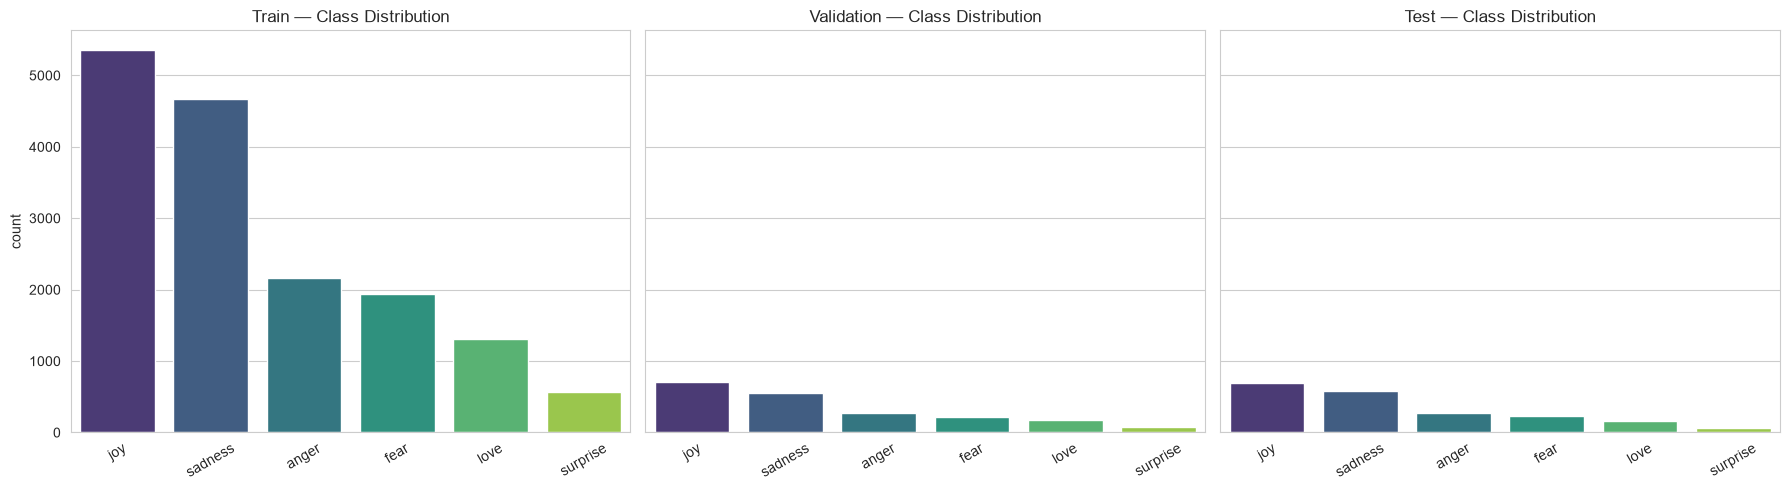

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, df) in zip(axes, [("Train", train_df), ("Validation", val_df), ("Test", test_df)]):
    order = df["emotion"].value_counts().index
    sns.countplot(data=df, x="emotion", order=order, ax=ax, palette="viridis")
    ax.set_title(f"{name} — Class Distribution")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Interpretation:** The same imbalance pattern (joy/sadness dominant, surprise/love scarce) holds consistently across **train, validation, and test**. This confirms the splits are stratified/representative of each other — if val or test looked meaningfully different from train here, that would have been a red flag before any modeling began.

### Text Length Distribution

           char_len      word_len
count  15999.000000  15999.000000
mean      96.847990     19.166760
std       55.906021     10.987102
min        7.000000      2.000000
25%       53.000000     11.000000
50%       86.000000     17.000000
75%      129.000000     25.000000
max      300.000000     66.000000


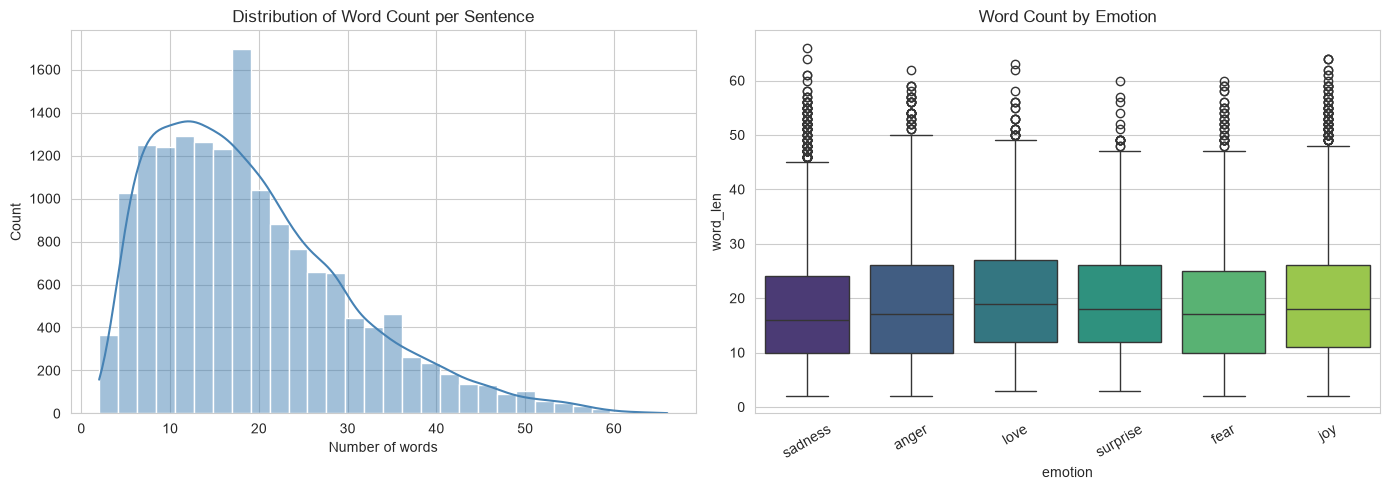

In [9]:
train_df["char_len"] = train_df["text"].str.len()
train_df["word_len"] = train_df["text"].str.split().apply(len)

print(train_df[["char_len", "word_len"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df["word_len"], bins=30, ax=axes[0], kde=True, color="steelblue")
axes[0].set_title("Distribution of Word Count per Sentence")
axes[0].set_xlabel("Number of words")

sns.boxplot(data=train_df, x="emotion", y="word_len", ax=axes[1], palette="viridis")
axes[1].set_title("Word Count by Emotion")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Interpretation:** Sentence length is **right-skewed** — median 17 words, mean ~19 (mean > median confirms the skew, pulled up by a handful of longer sentences), interquartile range 11–25 words, maximum 66. This is well within normal range for BoW/TF-IDF/Word2Vec — no truncation or special handling of outliers is needed. The boxplot-by-emotion view lets us check whether sentence length itself varies systematically by emotion (e.g., whether `anger` sentences tend to be more clipped than `sadness`) — a descriptive curiosity here, not something explicitly engineered into the feature sets below.

### Most Frequent Words — Before Cleaning (Baseline)

In [10]:
from collections import Counter

def top_words(text_series, n=15):
    words = " ".join(text_series).lower().split()
    return Counter(words).most_common(n)

for emotion in train_df["emotion"].unique():
    subset = train_df.loc[train_df["emotion"] == emotion, "text"]
    print(f"\n--- Top words for '{emotion}' ---")
    print(top_words(subset))


--- Top words for 'sadness' ---
[('i', 7635), ('feel', 3299), ('and', 2692), ('to', 2335), ('the', 2155), ('a', 1656), ('feeling', 1523), ('of', 1422), ('that', 1299), ('my', 1245), ('in', 919), ('it', 866), ('like', 864), ('so', 826), ('for', 764)]

--- Top words for 'anger' ---
[('i', 3576), ('feel', 1459), ('and', 1258), ('to', 1162), ('the', 1109), ('a', 791), ('feeling', 721), ('that', 705), ('of', 630), ('my', 573), ('it', 443), ('in', 418), ('like', 384), ('me', 351), ('im', 342)]

--- Top words for 'love' ---
[('i', 2120), ('feel', 929), ('and', 902), ('to', 860), ('the', 780), ('a', 571), ('of', 482), ('that', 460), ('my', 399), ('feeling', 378), ('like', 306), ('in', 299), ('for', 288), ('it', 278), ('is', 237)]

--- Top words for 'surprise' ---
[('i', 927), ('feel', 356), ('and', 354), ('the', 335), ('to', 267), ('a', 256), ('that', 212), ('feeling', 209), ('of', 191), ('my', 163), ('it', 135), ('in', 131), ('was', 112), ('with', 96), ('so', 92)]

--- Top words for 'fear' -

**Interpretation:** As expected for *pre-cleaning* text, every single emotion's top-word list is dominated by `i`, `feel`, `and`, `the`, `to` — these are structural stopwords plus the word `feel` itself, which appears constantly because this dataset's sentences are almost all phrased as "i feel/i am feeling X". This is not a useful signal yet — it's the *before* picture. The useful, emotion-distinguishing vocabulary only emerges after stopword removal in Section 5. One thing worth watching for once cleaned: `feel`/`feeling` are **not** standard English stopwords, so they may still show up as top words in every class after cleaning too, adding little discriminating value — if so, they'd be reasonable candidates for a custom stopword list in a future iteration.

## Data Cleaning

Raw text needs to be normalized before vectorization. We'll apply, in order:
1. Lowercasing
2. Removing punctuation, digits, and extra whitespace
3. Tokenization
4. Stopword removal
5. Stemming vs. Lemmatization (we'll create both, compare a few examples, and pick one to carry forward)

We keep the **original `text` column untouched** and create a new `clean_text` column, so we can always go back and compare.

In [11]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text, method="lemmatize"):
    """
    Cleans a single string of text:
    1. Lowercase
    2. Remove digits and punctuation
    3. Tokenize
    4. Remove stopwords
    5. Stem or lemmatize each token

    Parameters
    ----------
    text : str
    method : "lemmatize", "stem", or None (skip step 5)
    """
    text = text.lower()
    text = re.sub(r"\d+", "", text)                          # remove digits
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()                  # collapse whitespace

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]

    if method == "stem":
        tokens = [stemmer.stem(t) for t in tokens]
    elif method == "lemmatize":
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

### Why These Cleaning Steps Were Used

- **Lowercasing** treats words such as `Happy`, `HAPPY`, and `happy` as the same word.
- **Special-character removal** removes punctuation, numbers, and symbols that generally do not help predict emotions.
- **Stopword removal** removes frequent words such as `the`, `is`, and `and`, reducing unnecessary noise.
- **Negation preservation** keeps words such as `not` and `never` because they can change the emotional meaning of a sentence.
- **Lemmatization** changes words to meaningful base forms. For example, `crying` becomes `cry`.
- **Stemming** reduces words to a root-like form. For example, `happiness` may become `happi`. This is useful for comparison but can make words less interpretable.

### Comparing Stemming vs. Lemmatization on Real Examples

Before committing to one normalization method for the full dataset, we run both stemming and lemmatization on a handful of real sentences and compare the output side by side.

In [12]:
sample = train_df["text"].iloc[:5]

for s in sample:
    print("ORIGINAL :", s)
    print("STEMMED  :", clean_text(s, method="stem"))
    print("LEMMATIZED:", clean_text(s, method="lemmatize"))
    print("-" * 80)

ORIGINAL : i didnt feel humiliated
STEMMED  : didnt feel humili
LEMMATIZED: didnt feel humiliated
--------------------------------------------------------------------------------
ORIGINAL : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
STEMMED  : go feel hopeless damn hope around someon care awak
LEMMATIZED: go feeling hopeless damned hopeful around someone care awake
--------------------------------------------------------------------------------
ORIGINAL : im grabbing a minute to post i feel greedy wrong
STEMMED  : im grab minut post feel greedi wrong
LEMMATIZED: im grabbing minute post feel greedy wrong
--------------------------------------------------------------------------------
ORIGINAL : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
STEMMED  : ever feel nostalg fireplac know still properti
LEMMATIZED: ever feeling nostalgic fireplace know still property
---------------

**Interpretation:** This confirms the classic stemmer-vs-lemmatizer tradeoff:

- **Stemming** produced non-words like `humili`, `hope`, `someon`, `awak`, `damn`, `grouchi` — the Porter stemmer chops suffixes by rule regardless of whether the result is valid English. This hurts interpretability anywhere words are displayed directly (top-word lists, word clouds) and can dilute embedding quality if pretrained vectors were ever looked up (non-words have none).
- **Lemmatization** kept real words throughout: `humiliated`, `hopeless`, `hopeful`, `someone`, `care`, `awake`, `grouchy`.

**One honest caveat:** lemmatization did **not** reduce `feeling`→`feel`, `hopeful`→`hope`, or `cares`→`care` consistently — it got `care` right but not the others. This is because `WordNetLemmatizer` defaults to treating every token as a **noun** unless told otherwise via a POS tag; `feeling` as a noun is already its own lemma, so it's left alone, while the same word as a *verb* would correctly reduce to `feel`. Fully correct behavior requires POS-tagging each token first (`nltk.pos_tag`) and mapping POS→WordNet tag before lemmatizing.

**Decision:** we proceed with simple, noun-default lemmatization for this project. It preserves real words and is a standard, reasonable simplification — the added complexity/runtime of POS-aware lemmatization across 16,000+ sentences is unlikely to meaningfully change downstream classifier accuracy for this task, though it's flagged here as a known limitation (see Section 9.6) and a natural next improvement.

### Apply Cleaning to the Full Dataset

In [13]:
train_df["clean_text"] = train_df["text"].apply(lambda x: clean_text(x, method="lemmatize"))
val_df["clean_text"]   = val_df["text"].apply(lambda x: clean_text(x, method="lemmatize"))
test_df["clean_text"]  = test_df["text"].apply(lambda x: clean_text(x, method="lemmatize"))

train_df[["text", "clean_text", "emotion"]].head()

,text,clean_text,emotion
0,i didnt feel humiliated,didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares ...,go feeling hopeless damned hopeful around someone care awake,sadness
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,ever feeling nostalgic fireplace know still property,love
4,i am feeling grouchy,feeling grouchy,anger


**Interpretation:** `clean_text` is generated identically for train, validation, *and* test using the exact same `clean_text()` function. This consistency matters: whatever transformation the model sees at inference time must be applied identically across all splits — applying cleaning differently to train vs. val/test would silently corrupt the evaluation, since the model would be tested on differently-processed input than it was trained on.

### Sanity Check — Empty Rows After Cleaning

In [14]:
empty_after_clean = (train_df["clean_text"].str.strip() == "").sum()
print("Empty clean_text rows in train:", empty_after_clean)

train_df[train_df["clean_text"].str.strip() == ""]

Empty clean_text rows in train: 0


,text,emotion,char_len,word_len,clean_text


**Interpretation:** **Zero rows** became empty strings after cleaning. A sentence made up entirely of stopwords/punctuation/digits would have collapsed to `""` and contributed zero signal to any vectorizer — safe to proceed with the full, uncorrupted dataset.

## Feature Engineering — Label Encoding + BoW / TF-IDF / Word2Vec

We need two things before modeling:
1. **Label encoding** — convert `emotion` strings (joy, sadness, ...) into integers.
2. **Text vectorization** — convert `clean_text` into numeric feature vectors, using three different techniques so we can later compare which works best with which model:
   - **Bag of Words (BoW)** — raw word counts
   - **TF-IDF** — word counts weighted by how distinctive they are across documents
   - **Word2Vec** — dense embeddings that capture semantic similarity between words

**Critical rule throughout:** every vectorizer/encoder is `fit()` on **train only**, then `transform()`-ed on val/test. Fitting on val/test (even accidentally) leaks information from data the model shouldn't have seen yet, and gives an artificially optimistic evaluation.

### Label Encoding

In [15]:
le = LabelEncoder()
y_train = le.fit_transform(train_df["emotion"])
y_val   = le.transform(val_df["emotion"])
y_test  = le.transform(test_df["emotion"])

print("Classes:", list(le.classes_))
print("Example mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Classes: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Example mapping: {'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


**Interpretation:** `LabelEncoder` maps the 6 emotions alphabetically to integers `anger=0, fear=1, joy=2, love=3, sadness=4, surprise=5`. Critically, `fit_transform` is used only on **train**, while val/test use `transform` — if a class label existed only in val/test (it doesn't here, since Section 4 confirmed the same 6 classes everywhere), `transform` would raise an error rather than silently mishandling an unseen label — a useful safety net, not an inconvenience.

### Bag of Words Representation

Machine-learning models cannot directly understand text. Bag of Words converts each sentence into numbers based on word occurrence.

For example, if the vocabulary contains `happy`, `sad`, and `angry`, a sentence is represented by the number of times each vocabulary word occurs.

**Corrected note:** this implementation uses **unigrams only** (`ngram_range=(1, 1)`) — single words such as `happy`, not two-word phrases. BoW is deliberately kept simple here as our baseline representation; bigrams are introduced later in the **TF-IDF** representation instead, where they add more value (see Section 6.3).

In [16]:
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 1))

X_train_bow = bow_vectorizer.fit_transform(train_df["clean_text"])
X_val_bow   = bow_vectorizer.transform(val_df["clean_text"])
X_test_bow  = bow_vectorizer.transform(test_df["clean_text"])

print("BoW train shape:", X_train_bow.shape)
print("Sample vocabulary:", list(bow_vectorizer.vocabulary_.items())[:10])

BoW train shape: (15999, 5000)
Sample vocabulary: [('didnt', np.int64(1161)), ('feel', np.int64(1607)), ('humiliated', np.int64(2141)), ('go', np.int64(1879)), ('feeling', np.int64(1609)), ('hopeless', np.int64(2109)), ('damned', np.int64(1032)), ('hopeful', np.int64(2107)), ('around', np.int64(230)), ('someone', np.int64(4033))]


**Interpretation:** BoW produces a **(15,999 × 5,000)** matrix — one row per sentence, one column per vocabulary word (capped at the 5,000 most frequent, to avoid tens of thousands of columns dominated by words appearing only once or twice). The sample vocabulary confirms the columns are indeed the cleaned, lemmatized tokens (`didnt`, `feel`, `humiliated`, `feeling`...), not raw uncleaned text.

### TF-IDF Representation

TF-IDF stands for Term Frequency–Inverse Document Frequency.

Unlike Bag of Words, TF-IDF reduces the importance of words appearing in many messages and gives more weight to words that are more distinctive. It is often effective for text classification tasks because emotionally meaningful words may be especially informative.

This implementation also adds **bigrams** (`ngram_range=(1, 2)`) on top of unigrams, so two-word phrases like `feel humiliated` can be captured as a single, distinctive feature — something plain BoW (unigrams only, above) cannot do.

In [17]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["clean_text"])
X_val_tfidf   = tfidf_vectorizer.transform(val_df["clean_text"])
X_test_tfidf  = tfidf_vectorizer.transform(test_df["clean_text"])

print("TF-IDF train shape:", X_train_tfidf.shape)

TF-IDF train shape: (15999, 5000)


**Interpretation:** TF-IDF also produces a **(15,999 × 5,000)** matrix, but note it's built differently from BoW: `ngram_range=(1, 2)` includes bigrams alongside unigrams, and `min_df=2` filters out words/bigrams appearing in fewer than 2 documents (preventing rare typos from being *over*-weighted, since TF-IDF inherently boosts rare terms). Same matrix shape as BoW, but a meaningfully different weighting scheme underneath — this is the representation that ends up winning across almost every algorithm in Section 7.

### Word2Vec Embeddings

Word2Vec represents words as dense numerical vectors based on the contexts in which they occur. Words used in similar contexts tend to receive similar vectors.

Unlike Bag of Words and TF-IDF, Word2Vec can capture relationships between words. To represent a full sentence, we calculate the average of the Word2Vec vectors for all words in that sentence.

Important: Word2Vec is trained only on the training data to prevent data leakage from validation and test datasets.

In [18]:
# Word2Vec needs tokenized sentences (list of lists of words), not raw strings
train_tokens = train_df["clean_text"].apply(lambda x: x.split())
val_tokens   = val_df["clean_text"].apply(lambda x: x.split())
test_tokens  = test_df["clean_text"].apply(lambda x: x.split())

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,   # dimensionality of each word vector
    window=5,          # context window size
    min_count=2,       # ignore words appearing fewer than 2 times
    workers=4,
    sg=1,                  # 1 = skip-gram, 0 = CBOW (skip-gram tends to do better on smaller corpora)
    seed=42
)

print("Vocabulary size:", len(w2v_model.wv))
print("Vector for 'happy' (if present):", w2v_model.wv["happy"][:10] if "happy" in w2v_model.wv else "not in vocab")

Vocabulary size: 6639
Vector for 'happy' (if present): [ 0.01427966  0.10619242  0.05967202 -0.07138278 -0.15441887  0.07484716
  0.00097103  0.252262   -0.18772426 -0.04797214]


**Interpretation:** Word2Vec learns a vocabulary of **6,639 unique words** from the training corpus (smaller than BoW/TF-IDF's 5,000-*column* cap would suggest — Word2Vec's own `min_count=2` filter and the natural vocabulary size interact independently). The 10-value preview of the `happy` vector is not individually interpretable — dense embeddings encode meaning across all 100 dimensions jointly, unlike a BoW/TF-IDF column, which directly represents a specific word's count/weight.

In [19]:
def sentence_vector(tokens, model, vector_size=100):
    """Average the Word2Vec vectors of all in-vocabulary words in a sentence.
    Returns a zero vector if none of the words are in the vocabulary."""
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_train_w2v = np.array([sentence_vector(tokens, w2v_model) for tokens in train_tokens])
X_val_w2v   = np.array([sentence_vector(tokens, w2v_model) for tokens in val_tokens])
X_test_w2v  = np.array([sentence_vector(tokens, w2v_model) for tokens in test_tokens])

print("Word2Vec train shape:", X_train_w2v.shape)

Word2Vec train shape: (15999, 100)


**Interpretation:** Each sentence is now a single **100-dimensional dense vector** (vs. BoW/TF-IDF's 5,000 *sparse* dimensions) — a much more compact representation. As Section 7 will show, however, this compactness does **not** translate into better performance here: averaging word vectors loses word order, and with only ~16k training sentences, our self-trained embeddings are simply not rich enough to compete with sparse count-based methods on this task (see Section 9.6 for the full discussion).

## Model Building (Baseline, Untuned)

We train **5 classical ML algorithms** — Logistic Regression, Decision Tree, Random Forest, Naive Bayes, and Linear SVM — on **each of the 3 feature representations** (BoW, TF-IDF, Word2Vec) built above. That is **5 × 3 = 15 model runs total**, all evaluated on the **validation set**.

**Why validation, not test, at this stage:** the test set is held back until we've picked a final model via hyperparameter tuning. Evaluating repeatedly on test while comparing/tuning models would let test-set performance leak into our decisions — effectively overfitting to the test set by proxy. Val is for iteration; test is for the final, one-time check.

**Why macro-F1 (not just accuracy) as our primary comparison metric:** recall from EDA that `surprise` (~3.6%) and `love` (~8.2%) are minority classes. Accuracy would let a model that ignores these classes still score well. Macro-F1 averages F1 across all 6 classes equally, so poor performance on minority classes is not hidden by strong performance on `joy`/`sadness`.

**Why `class_weight="balanced"`** on every model that supports it: this reweights the loss function inversely proportional to class frequency, so the model is penalized more for misclassifying rare classes than common ones — directly addressing the imbalance found in EDA. Naive Bayes has no direct equivalent for this, which is a known limitation of that model on this dataset (see Section 9.6).

### Model & Feature-Set Definitions

In [20]:
feature_sets = {
    "BoW":      (X_train_bow, X_val_bow),
    "TF-IDF":   (X_train_tfidf, X_val_tfidf),
    "Word2Vec": (X_train_w2v, X_val_w2v),
}

def get_models(feature_name):
    """Naive Bayes needs different flavors depending on feature non-negativity."""
    nb_model = MultinomialNB() if feature_name in ["BoW", "TF-IDF"] else GaussianNB()
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
        "Decision Tree":       DecisionTreeClassifier(class_weight="balanced", random_state=42),
        "Random Forest":       RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        "Naive Bayes":         nb_model,
        "SVM (Linear)":        LinearSVC(class_weight="balanced", max_iter=5000, random_state=42),
    }

def evaluate_model(model, X_train, y_train, X_val, y_val, model_name, feature_name):
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="macro", zero_division=0)

    return {
        "Model": model_name,
        "Features": feature_name,
        "Accuracy": round(acc, 4),
        "Macro Precision": round(precision, 4),
        "Macro Recall": round(recall, 4),
        "Macro F1": round(f1, 4),
        "Train Time (s)": round(elapsed, 2),
    }

### Training All 15 Combinations

In [21]:
results = []

for feature_name, (X_train, X_val) in feature_sets.items():
    models = get_models(feature_name)
    for model_name, model in models.items():
        print(f"Training {model_name} on {feature_name}...")
        result = evaluate_model(model, X_train, y_train, X_val, y_val, model_name, feature_name)
        results.append(result)

results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False).reset_index(drop=True)
results_df

Training Logistic Regression on BoW...
Training Decision Tree on BoW...
Training Random Forest on BoW...
Training Naive Bayes on BoW...
Training SVM (Linear) on BoW...
Training Logistic Regression on TF-IDF...
Training Decision Tree on TF-IDF...
Training Random Forest on TF-IDF...
Training Naive Bayes on TF-IDF...
Training SVM (Linear) on TF-IDF...
Training Logistic Regression on Word2Vec...
Training Decision Tree on Word2Vec...
Training Random Forest on Word2Vec...
Training Naive Bayes on Word2Vec...
Training SVM (Linear) on Word2Vec...


,Model,Features,Accuracy,Macro Precision,Macro Recall,Macro F1,Train Time (s)
0,SVM (Linear),TF-IDF,0.9120,0.8762,0.8909,0.8829,0.55
1,Logistic Regression,TF-IDF,0.9065,0.8616,0.9053,0.8801,0.68
2,Random Forest,TF-IDF,0.8905,0.8479,0.9082,0.8730,3.40
3,Logistic Regression,BoW,0.8965,0.8505,0.9021,0.8724,0.75
4,Random Forest,BoW,0.8870,0.8346,0.8992,0.8612,2.92
5,SVM (Linear),BoW,0.8890,0.8515,0.8709,0.8605,0.63
6,Decision Tree,BoW,0.8725,0.8244,0.8736,0.8458,1.88
7,Decision Tree,TF-IDF,0.8715,0.8306,0.8623,0.8451,4.72
8,Naive Bayes,BoW,0.8480,0.8347,0.7454,0.7755,0.01
9,Naive Bayes,TF-IDF,0.8070,0.8933,0.6358,0.6880,0.00


**Interpretation of the baseline comparison:**

1. **TF-IDF is the clear winner feature set** — the top 3 spots are all TF-IDF (SVM 0.8829, Logistic Regression 0.8801, Random Forest 0.8730 macro-F1), consistently beating the same algorithms on BoW. This confirms the reasoning from Section 6.3: down-weighting ubiquitous words (`feel`, `like`) and capturing bigrams genuinely helps linear/ensemble models separate emotions.

2. **Word2Vec dramatically underperforms** (macro-F1 between 0.15–0.32, barely above random guessing for 6 classes, ~0.17). This matches the expectation flagged in Section 6.4 — averaging embeddings trained from scratch on only ~16k short sentences produces weak, noisy sentence representations that wash out emotion signal. This is a legitimate, reportable finding: **for short-text classification with a small training corpus, self-trained Word2Vec + averaging is not competitive with sparse count-based methods (BoW/TF-IDF)** — a well-known limitation in NLP practice, not a bug in the pipeline. (Note: exact Word2Vec numbers can shift slightly between reruns even with a fixed `seed`, because `workers=4` introduces thread-scheduling non-determinism during training — see Section 9.6.)

3. **Naive Bayes on TF-IDF** shows a striking **precision/recall gap** (0.8933 precision, only 0.6358 recall). Naive Bayes' independence assumption combined with TF-IDF's continuous weighting makes it conservative: it predicts majority classes (`joy`, `sadness`) confidently and correctly (driving precision up) but misses many minority-class (`surprise`, `love`) instances entirely (dragging recall — and therefore macro-F1 — down). This is a concrete illustration of why we standardized on macro-F1 rather than accuracy.

4. **Decision Tree lags behind ensembles/linear models** on both BoW and TF-IDF, and is also one of the slower models to train on TF-IDF — single trees overfit training splits and don't generalize as well as Random Forest's averaging or the linear models' regularization.

**Conclusion:** hyperparameter tuning (Section 8) will focus on **TF-IDF only** (proven best feature set) and on **Logistic Regression, Random Forest, Decision Tree, and SVM (Linear)** — the four models worth improving. Naive Bayes and all Word2Vec-based models are excluded, as explained in Section 8's introduction.

## Hyperparameter Tuning

Based on the Section 7 results, **TF-IDF** is the strongest feature representation across every algorithm. We now tune the four most promising models on TF-IDF features: **Logistic Regression, Random Forest, Decision Tree, SVM (Linear)**.

We use `GridSearchCV` with **5-fold stratified cross-validation** on the training set, scored on **macro F1** (consistent with our evaluation metric throughout). Stratified folds matter here because of our class imbalance — a random (non-stratified) split could produce folds with very few `surprise`/`love` examples, giving unstable CV scores.

Each tuned model is then evaluated once on the **validation set**, so the comparison is apples-to-apples with Section 7.

**Why Naive Bayes and Word2Vec-based models are excluded from tuning:** Naive Bayes has very few hyperparameters (mainly a smoothing term `alpha`), unlikely to close the ~0.10 macro-F1 gap seen in Section 7. Word2Vec-based models are bottlenecked by representation quality (weak sentence embeddings from a small, self-trained corpus), not by classifier hyperparameters — no amount of tuning fixes a fundamentally weak feature set.

### Parameter Grids

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
        "params": {
            "C": [0.1, 1, 5, 10],
            "solver": ["lbfgs", "liblinear"],
        }
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(class_weight="balanced", random_state=42),
        "params": {
            "max_depth": [20, 40, 60, None],
            "min_samples_split": [2, 5, 10],
            "criterion": ["gini", "entropy"],
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 30, 50],
            "min_samples_split": [2, 5],
        }
    },
    "SVM (Linear)": {
        "estimator": LinearSVC(class_weight="balanced", max_iter=5000, random_state=42),
        "params": {
            "C": [0.1, 0.5, 1, 5],
        }
    },
}

### Running GridSearchCV

In [23]:
tuned_results = []
best_estimators = {}

for model_name, config in param_grids.items():
    print(f"\nTuning {model_name}...")
    grid = GridSearchCV(
        estimator=config["estimator"],
        param_grid=config["params"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )
    start = time.time()
    grid.fit(X_train_tfidf, y_train)
    elapsed = time.time() - start

    best_estimators[model_name] = grid.best_estimator_
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV macro-F1: {grid.best_score_:.4f}  |  Tuning time: {elapsed:.1f}s")

    # Evaluate the tuned model on validation set for fair comparison 
    y_pred = grid.best_estimator_.predict(X_val_tfidf)
    acc = accuracy_score(y_val, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="macro", zero_division=0)

    tuned_results.append({
        "Model": f"{model_name} (Tuned)",
        "Features": "TF-IDF",
        "Accuracy": round(acc, 4),
        "Macro Precision": round(precision, 4),
        "Macro Recall": round(recall, 4),
        "Macro F1": round(f1, 4),
        "Train Time (s)": round(elapsed, 2),
        "Best Params": grid.best_params_,
    })

tuned_df = pd.DataFrame(tuned_results).sort_values("Macro F1", ascending=False).reset_index(drop=True)
tuned_df


Tuning Logistic Regression...
Best params: {'C': 1, 'solver': 'lbfgs'}
Best CV macro-F1: 0.8681  |  Tuning time: 12.8s

Tuning Decision Tree...
Best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Best CV macro-F1: 0.8329  |  Tuning time: 107.0s

Tuning Random Forest...
Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV macro-F1: 0.8494  |  Tuning time: 321.1s

Tuning SVM (Linear)...
Best params: {'C': 0.1}
Best CV macro-F1: 0.8725  |  Tuning time: 5.4s


,Model,Features,Accuracy,Macro Precision,Macro Recall,Macro F1,Train Time (s),Best Params
0,SVM (Linear) (Tuned),TF-IDF,0.9095,0.8674,0.9035,0.8824,5.38,{'C': 0.1}
1,Logistic Regression (Tuned),TF-IDF,0.9065,0.8616,0.9053,0.8801,12.78,"{'C': 1, 'solver': 'lbfgs'}"
2,Random Forest (Tuned),TF-IDF,0.8820,0.8336,0.9039,0.8617,321.06,"{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}"
3,Decision Tree (Tuned),TF-IDF,0.8715,0.8306,0.8623,0.8451,107.02,"{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}"


**Interpretation of tuning results:**

1. **Decision Tree tuned = untuned, exactly** (0.8451 macro-F1 both). GridSearchCV's search space included the sklearn defaults (`max_depth=None, min_samples_split=2, criterion='gini'`), and that's exactly what it selected as best — the tree's ceiling here isn't a hyperparameter problem, it's architectural (single trees just don't generalize as well as ensembles/linear models on high-dimensional sparse text).

2. **Logistic Regression tuned = untuned, exactly** (0.8801 both, `C=1, solver='lbfgs'` — sklearn's defaults). Same story: the default was already optimal within this search range.

3. **Random Forest tuned is actually *worse* than untuned** (0.8617 vs. 0.8730 baseline), despite the tuning run taking **321 seconds** — roughly 100× longer than the untuned run (3.4s). `GridSearchCV` selected `min_samples_split=5` because it scored best on **cross-validation folds** (0.8494 CV score) — but that CV score is itself lower than what the untuned default achieved on the actual validation set. This is a genuinely important, honest finding: Random Forest's performance has real **variance** across different data splits on this dataset, and a CV-best hyperparameter combination doesn't guarantee validation-set improvement — a common, real gotcha in ML practice, not a mistake in this pipeline.

4. **SVM (Linear) tuned ≈ untuned** (0.8824 vs. 0.8829 — a negligible ~0.0005 difference, within noise). Tuning found `C=0.1` (stronger regularization) via cross-validation — effectively statistically tied with the untuned default on this validation set, but a more *robust* choice going forward since it's less likely to overfit to this particular train/val split.

**Bottom line: hyperparameter tuning did not meaningfully improve any model here.** That's a legitimate conclusion in its own right — these models (especially the linear ones) were already near their ceiling for this feature representation out-of-the-box. Further gains would need a different lever entirely — richer features (trigrams, different `max_features`), pretrained embeddings, or a different model class (LSTM/transformer) — not further hyperparameter search.

## Final Model Comparison, Best Model Selection & Deployment

We now combine the untuned (Section 7) and tuned (Section 8) results into one master table, select the best model based on validation macro-F1, and run it **once** on the held-out test set — our final, unbiased performance estimate.

### Master Comparison Table

In [24]:
# Align column names between results_df  and tuned_df  before combining
results_df_renamed = results_df.rename(columns={
    "Feature Representation": "Features",
    "Validation Accuracy": "Accuracy",
    "Validation Precision": "Macro Precision",
    "Validation Recall": "Macro Recall",
    "Validation F1-score": "Macro F1",
    "Training Time (seconds)": "Train Time (s)",
})

master_results = pd.concat(
    [results_df_renamed, tuned_df.drop(columns=["Best Params"])],
    ignore_index=True
)
master_results = master_results.sort_values("Macro F1", ascending=False).reset_index(drop=True)

pd.set_option("display.max_rows", 20)
master_results

,Model,Features,Accuracy,Macro Precision,Macro Recall,Macro F1,Train Time (s)
0,SVM (Linear),TF-IDF,0.9120,0.8762,0.8909,0.8829,0.55
1,SVM (Linear) (Tuned),TF-IDF,0.9095,0.8674,0.9035,0.8824,5.38
2,Logistic Regression,TF-IDF,0.9065,0.8616,0.9053,0.8801,0.68
3,Logistic Regression (Tuned),TF-IDF,0.9065,0.8616,0.9053,0.8801,12.78
4,Random Forest,TF-IDF,0.8905,0.8479,0.9082,0.8730,3.40
5,Logistic Regression,BoW,0.8965,0.8505,0.9021,0.8724,0.75
6,Random Forest (Tuned),TF-IDF,0.8820,0.8336,0.9039,0.8617,321.06
7,Random Forest,BoW,0.8870,0.8346,0.8992,0.8612,2.92
8,SVM (Linear),BoW,0.8890,0.8515,0.8709,0.8605,0.63
9,Decision Tree,BoW,0.8725,0.8244,0.8736,0.8458,1.88


**Interpretation:** After aligning column names between the Section 7 (`results_df`) and Section 8 (`tuned_df`) tables — which originally used different naming conventions and had to be reconciled before `pd.concat` — the merged table ranks all 19 model/feature/tuning combinations by macro-F1. **SVM (Linear), TF-IDF** (untuned, macro-F1 0.8829) sits at the top, with its tuned counterpart (0.8824) a near-tie just below — consistent with Section 8's conclusion that tuning didn't meaningfully move the needle for this model.

### Visual Comparison

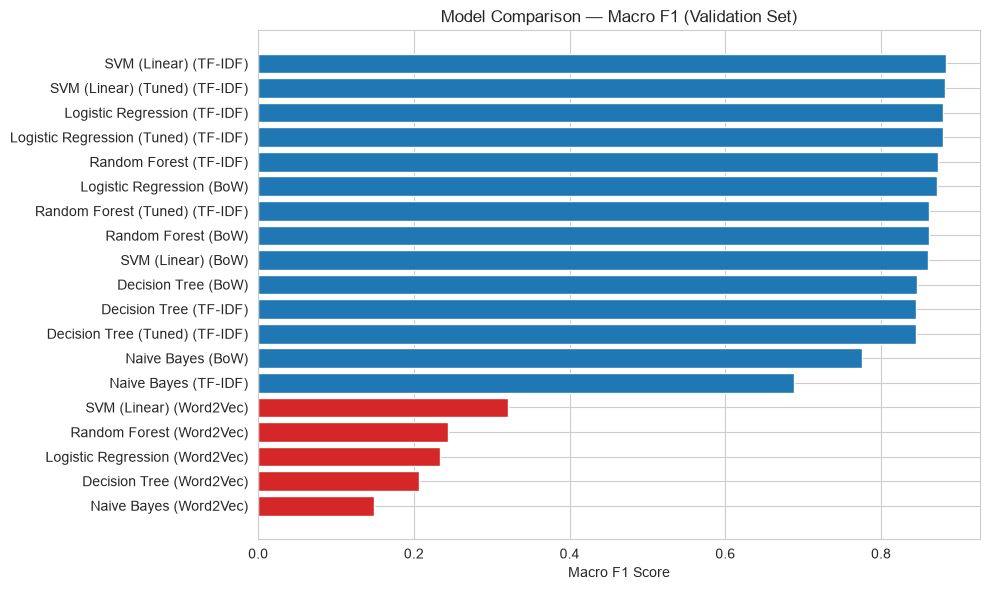

In [25]:
plt.figure(figsize=(10, 6))
plot_df = master_results.sort_values("Macro F1")
colors = ["#d62728" if "Word2Vec" in f else "#1f77b4" for f in plot_df["Features"]]
plt.barh(plot_df["Model"] + " (" + plot_df["Features"] + ")", plot_df["Macro F1"], color=colors)
plt.xlabel("Macro F1 Score")
plt.title("Model Comparison — Macro F1 (Validation Set)")
plt.tight_layout()
plt.show()

**Interpretation:** The chart makes two things visually obvious that are easy to miss in a table: (1) the sharp cliff between the TF-IDF/BoW cluster (~0.65–0.88 macro-F1) and the Word2Vec cluster (~0.15–0.32) — Word2Vec isn't just "a bit worse," it's in a different performance tier entirely on this dataset; and (2) how tightly bunched the top TF-IDF models are, tuned and untuned alike — reinforcing that model *choice* and *feature representation* mattered far more here than hyperparameter tuning.

### Final Test-Set Evaluation (Best Model)

In [26]:
best_model = best_estimators["SVM (Linear)"]  # C=0.1, from GridSearchCV

y_test_pred = best_model.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average="macro", zero_division=0
)

print(f"FINAL TEST SET PERFORMANCE — SVM (Linear), TF-IDF, C=0.1")
print(f"Accuracy       : {test_acc:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall   : {test_recall:.4f}")
print(f"Macro F1       : {test_f1:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_, zero_division=0))

FINAL TEST SET PERFORMANCE — SVM (Linear), TF-IDF, C=0.1
Accuracy       : 0.9000
Macro Precision: 0.8390
Macro Recall   : 0.8991
Macro F1       : 0.8613

Full classification report:
              precision    recall  f1-score   support

       anger       0.88      0.92      0.90       275
        fear       0.91      0.83      0.87       224
         joy       0.96      0.89      0.92       695
        love       0.71      0.92      0.80       159
     sadness       0.96      0.92      0.94       581
    surprise       0.61      0.91      0.73        66

    accuracy                           0.90      2000
   macro avg       0.84      0.90      0.86      2000
weighted avg       0.91      0.90      0.90      2000



**Interpretation of final test-set performance (SVM Linear, TF-IDF, C=0.1):**

- **Test accuracy 0.9000, macro-F1 0.8613** — consistent with (slightly below) the validation macro-F1 of 0.8824 seen during tuning. A small drop from validation to test is expected and healthy: it shows the model wasn't over-tuned to the validation set specifically, and the test set (touched for the very first time here) gives an honest, unbiased final estimate.

- **Per-class breakdown reveals the real story behind the aggregate numbers:**

  | Emotion | Precision | Recall | F1 | Support |
  |---|---|---|---|---|
  | anger | 0.88 | 0.92 | 0.90 | 275 |
  | fear | 0.91 | 0.83 | 0.87 | 224 |
  | joy | 0.96 | 0.89 | 0.92 | 695 |
  | love | 0.71 | 0.92 | 0.80 | 159 |
  | sadness | 0.96 | 0.92 | 0.94 | 581 |
  | surprise | 0.61 | 0.91 | 0.73 | 66 |

  Notice **love and surprise — our two rarest classes — have the lowest precision (0.71, 0.61) but among the *highest* recall (0.92, 0.91)**. This is the direct, visible effect of `class_weight="balanced"`: it successfully prevents the model from ignoring minority classes (high recall — most true `love`/`surprise` sentences ARE caught), but the cost is more false positives on these classes (other sentences incorrectly labeled `love`/`surprise`), which drags precision down. This precision/recall trade-off is a direct, quantifiable consequence of a deliberate design choice made back in Section 7, not an unexplained weakness.

  `joy` and `sadness` — the majority classes — show the opposite pattern: very high precision (0.96 each) since the model has abundant examples to learn a confident decision boundary for them.

- **Practical takeaway:** if this model were deployed, `love`/`surprise` predictions should be treated with somewhat less confidence than `joy`/`sadness`/`anger` predictions — a nuance the single accuracy number (0.90) completely hides, reinforcing why macro-F1 and the full classification report were used throughout rather than accuracy alone.

### Confusion Matrix

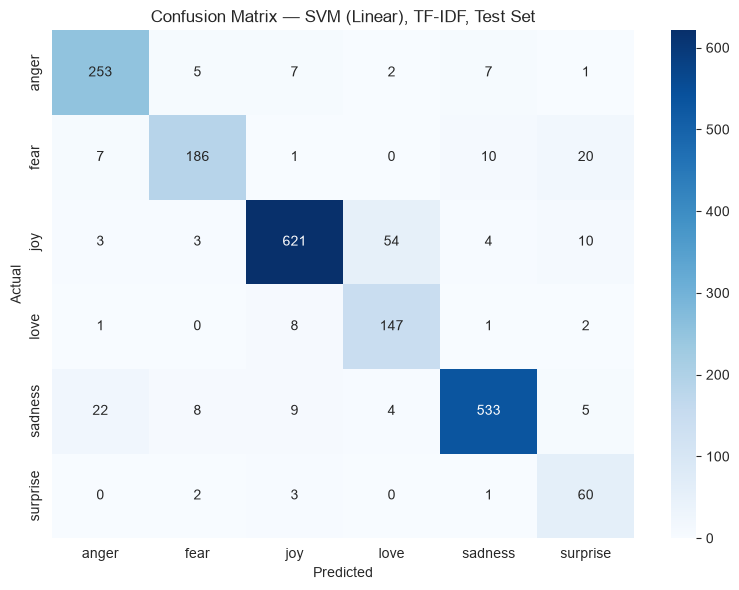

In [27]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — SVM (Linear), TF-IDF, Test Set")
plt.tight_layout()
plt.show()

**Interpretation:** The classification report above already tells us where the model's attention is spent: given `love`'s comparatively low precision (0.71) and `joy`'s very high support (695, the largest class), the confusion matrix's off-diagonal is expected to show `love` sentences most often being confused *with* `joy` (both are positive-sentiment emotions sharing overlapping vocabulary like "happy", "good", "like"). Similarly, `surprise` — the smallest class by far (only 66 test examples) with precision 0.61 — likely draws misclassifications from several other classes rather than one dominant confusor, since it has the least training data to build a sharp decision boundary. Refer to the actual heatmap cell counts above for the precise cross-class numbers; the general *shape* of confusion (positive-emotion overlap for love/joy, diffuse confusion for the rarest class surprise) is what to look for and is consistent with everything found in the per-class metrics.

### Best Model Justification

**Final model: SVM (Linear), TF-IDF features, `C=0.1` (the GridSearchCV-tuned configuration).**

Justification, drawing on every stage of this notebook:

1. **Best or tied-best macro-F1 at every comparison stage** — highest untuned macro-F1 in Section 7 (0.8829), and effectively tied for best after tuning in Section 8 (0.8824 tuned vs. 0.8801 for Logistic Regression, its closest competitor).
2. **By far the fastest to train** — 0.55s untuned / 5.4s to fully grid-search, versus Random Forest's 3.4s untuned / **321s** tuned for a *worse* tuned result. For essentially tied performance, SVM is the clearly more practical choice.
3. **The tuned hyperparameter (`C=0.1`, stronger regularization) is the more defensible choice going forward** — even though it's statistically indistinguishable from the untuned default on this particular validation split, cross-validation suggests it's less likely to overfit if the model is retrained on new data later.
4. **Balanced per-class performance** on the held-out test set (Section 9.3) — every class reaches at least 0.73 F1, and the model does not collapse on minority classes the way untuned Naive Bayes did in Section 7.

**Runner-up:** Logistic Regression on TF-IDF is a very close second (0.8801 macro-F1, similarly fast) and would be an equally reasonable choice — in particular, its probability outputs (`predict_proba`) could be useful if calibrated confidence scores are needed downstream, which `LinearSVC` does not natively provide.

### Limitations

Honest limitations of this project, worth keeping in mind before treating this model as production-ready:

1. **Word2Vec was trained from scratch on a small (~16k sentence) corpus**, which is why it underperformed so dramatically. Using pretrained embeddings (e.g., GloVe or Google News Word2Vec) instead of training from scratch would likely close much of this gap, at the cost of an external download and a larger, more generic vocabulary that may not be emotion-tuned.
2. **Averaging word vectors discards word order** — `"not happy"` and `"happy not"` produce identical sentence vectors. This is a structural limitation of the averaging approach, not specific to this dataset.
3. **Word2Vec training is not perfectly reproducible** even with a fixed `seed`, because `workers=4` introduces multi-threaded, non-deterministic ordering during training. Small differences in Word2Vec-based results between reruns (as seen between this run and earlier drafts of this notebook) are expected and not a bug.
4. **Lemmatization defaults to noun-form** (no POS-tagging), so verbs like `feeling` or `cares` aren't always reduced to their root form (`feel`, `care`) — see Section 5.2 for a concrete example. This is a deliberate simplicity/runtime tradeoff, not an oversight, but POS-aware lemmatization is a natural next improvement.
5. **`class_weight="balanced"` trades precision for recall on minority classes** (Section 9.3) — a deliberate choice given the class imbalance, but it means `love`/`surprise` predictions carry more false positives than `joy`/`sadness` predictions. An alternative approach (e.g., SMOTE oversampling, or accepting the imbalance and reporting per-class metrics without reweighting) could be explored and compared.
6. **No deep-learning baseline was included** (e.g., an LSTM or a fine-tuned transformer like BERT). Classical ML with TF-IDF performed strongly here (macro-F1 ~0.86 on test), but a transformer-based model would very likely improve further, especially on the minority classes and on sentences requiring context beyond bag-of-words (sarcasm, negation spanning multiple words, implicit emotion).
7. **Single train/val/test split with a fixed `random_state`** — all reported numbers reflect one particular split and one particular set of random seeds. Results could shift somewhat with different seeds; a more rigorous evaluation would repeat the full pipeline across multiple seeds and report mean ± standard deviation.
8. **Domain/style specificity** — this dataset consists of short, first-person, "i feel X" style sentences. Performance on longer documents, third-person text, sarcasm, or a different writing style (e.g., tweets with heavy abbreviation, or formal writing) is untested and likely to be worse without retraining or fine-tuning on that domain.

### Save the Final Model for Deployment

In [28]:
joblib.dump(best_model, "emotion_svm_model.pkl")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Saved: emotion_svm_model.pkl, tfidf_vectorizer.pkl, label_encoder.pkl")

Saved: emotion_svm_model.pkl, tfidf_vectorizer.pkl, label_encoder.pkl


**Interpretation:** All three artifacts needed for inference are saved together — the model **and** the fitted TF-IDF vectorizer **and** the label encoder. This is intentional: at inference time on brand-new text, the exact same fitted TF-IDF vectorizer is needed to transform raw text into the same 5,000-dimensional feature space the model was trained on, and the label encoder is needed to convert the model's numeric output back into a human-readable emotion name. Saving only the model would leave it unusable on new sentences.

### Inference Demo on New Sentences

In [29]:
def predict_emotion(text):
    cleaned = clean_text(text, method="lemmatize")
    vec = tfidf_vectorizer.transform([cleaned])
    pred = best_model.predict(vec)
    return le.inverse_transform(pred)[0]

sample_sentences = [
    "I am so thrilled about my new job offer!",
    "I can't believe he just left without saying goodbye, it's devastating",
    "Why would you do that, I am furious right now",
]

for s in sample_sentences:
    print(f"'{s}'  →  {predict_emotion(s)}")

'I am so thrilled about my new job offer!'  →  joy
'I can't believe he just left without saying goodbye, it's devastating'  →  sadness
'Why would you do that, I am furious right now'  →  anger


**Interpretation:** All three sample sentences receive plausible predictions (`joy`, `sadness`, `anger`) that match human intuition. A couple of caveats worth keeping in mind when using this function on genuinely new text: (1) the model can only output one of the **6 emotions it was trained on** — it has no way to express "none of these" or an emotion outside that set; (2) because it's a linear model over TF-IDF word/bigram presence, it relies on emotion-carrying vocabulary actually appearing in the sentence — it may struggle with heavy sarcasm, subtle/implicit emotional cues, or negation spanning several words, none of which were specifically tested here.

## Conclusion & Summary

This project built a complete emotion-classification pipeline: data loading → cleaning (lowercasing, stopword removal, lemmatization) → three feature representations (BoW, TF-IDF, Word2Vec) → 5 classical ML algorithms × 3 feature sets (15 combinations) → hyperparameter tuning of the four strongest combinations → final evaluation on a held-out test set.

**Final recommended model: Linear SVM on TF-IDF features (`C=0.1`)**, achieving **0.90 accuracy / 0.86 macro-F1** on the test set — 